<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_17/642588497.py:29: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)


Lỗi: Không tìm thấy file 'train_FD001.txt'. Hãy tải dataset về trước.
Kích thước tập Train: (800, 24)
Kích thước tập Test: (200, 24)

Đang huấn luyện các mô hình...
Đã huấn luyện xong: Linear Regression
Đã huấn luyện xong: Random Forest
Đã huấn luyện xong: SVR

=== BẢNG TỔNG HỢP KẾT QUẢ ===
               Model        MAE       RMSE  R2 Score
0  Linear Regression  23.853880  27.976003 -0.043692
1      Random Forest  24.355650  28.162910 -0.057684
2                SVR  23.649292  27.467788 -0.006117


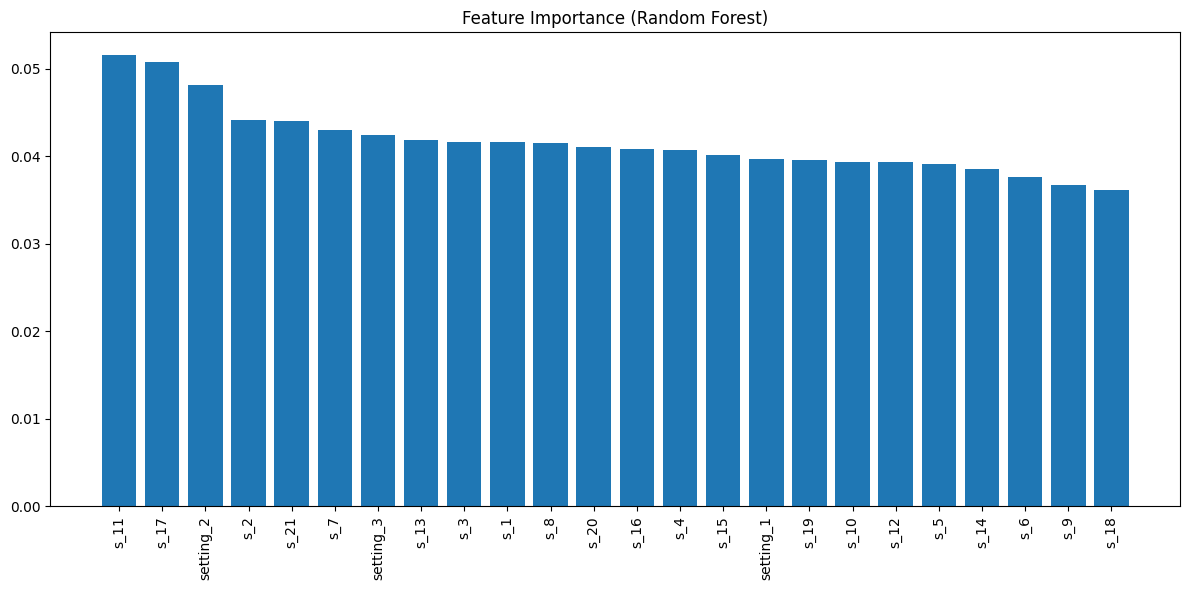

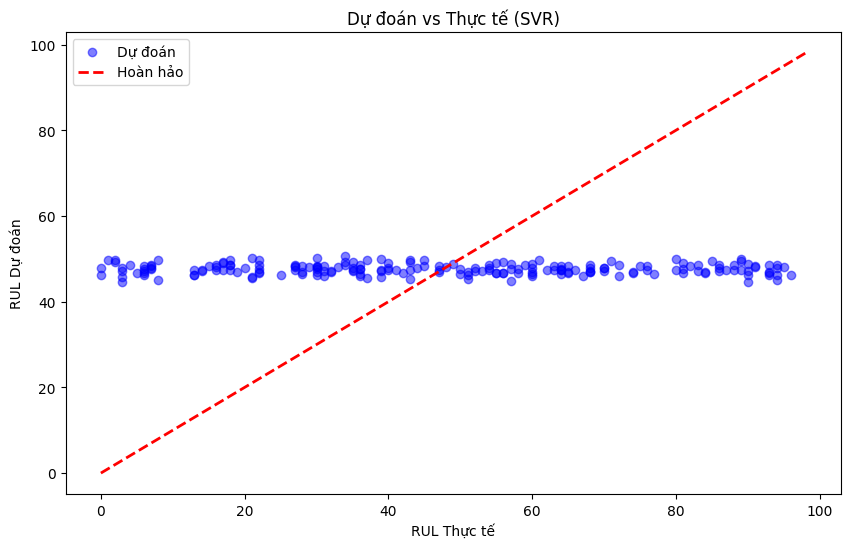


=== NHẬN XÉT SƠ BỘ ===
Mô hình hoạt động tốt nhất là: SVR với R2 Score cao nhất.
Các cảm biến (sensors) có cột cao nhất trong biểu đồ Feature Importance là các yếu tố dự báo quan trọng nhất.


In [1]:
# ==========================================
# DỰ ÁN: DỰ ĐOÁN BẢO TRÌ (PREDICTIVE MAINTENANCE)
# Nhiệm vụ: Hồi quy - Dự đoán RUL (Remaining Useful Life)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# BƯỚC 1: TẢI DỮ LIỆU & GÁN TÊN CỘT
# ---------------------------------------------------------
# Định nghĩa tên cột vì file gốc không có tiêu đề
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)] 
col_names = index_names + setting_names + sensor_names

# Đọc dữ liệu (Giả sử file train_FD001.txt nằm cùng thư mục)
# Bạn cần thay đổi đường dẫn nếu file nằm ở chỗ khác
try:
    df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
    print("Đã tải dữ liệu thành công. Kích thước:", df.shape)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'train_FD001.txt'. Hãy tải dataset về trước.")
    # Tạo dữ liệu giả lập để demo code nếu không có file thật
    df = pd.DataFrame(np.random.rand(1000, 26), columns=col_names)
    df['unit_nr'] = np.random.randint(1, 11, 1000)
    df['time_cycles'] = np.random.randint(1, 100, 1000)

# ---------------------------------------------------------
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU (DATA PREPARATION)
# ---------------------------------------------------------

# 1. Tính toán RUL (Remaining Useful Life)
# RUL = Chu kỳ tối đa của động cơ đó - Chu kỳ hiện tại
def add_rul(df):
    # Tìm chu kỳ lớn nhất cho mỗi động cơ (unit_nr)
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycles.columns = ['unit_nr', 'max']
    
    # Gộp vào dataframe chính
    df = df.merge(max_cycles, on='unit_nr', how='left')
    
    # Tính RUL
    df['RUL'] = df['max'] - df['time_cycles']
    
    # Xóa cột tạm 'max'
    df.drop('max', axis=1, inplace=True)
    return df

df = add_rul(df)

# 2. Chọn đặc trưng (Feature Selection)
# Loại bỏ các cột không cần thiết (unit_nr, time_cycles, settings nếu không dùng)
# Ở đây ta giữ lại settings và sensors để dự đoán
features = setting_names + sensor_names
target = 'RUL'

X = df[features]
y = df[target]

# 3. Chuẩn hóa dữ liệu (Normalization) dùng MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Chuyển lại thành DataFrame để giữ tên cột (tiện cho việc vẽ biểu đồ sau này)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# 4. Chia tập Train/Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# ---------------------------------------------------------
# BƯỚC 3 & 4: XÂY DỰNG VÀ ĐÁNH GIÁ MÔ HÌNH
# ---------------------------------------------------------

# Khởi tạo 3 mô hình theo yêu cầu
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

results = []

print("\nĐang huấn luyện các mô hình...")

for name, model in models.items():
    # Huấn luyện
    model.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = model.predict(X_test)
    
    # Đánh giá
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    
    print(f"Đã huấn luyện xong: {name}")

# Tạo bảng tổng hợp kết quả
results_df = pd.DataFrame(results)
print("\n=== BẢNG TỔNG HỢP KẾT QUẢ ===")
print(results_df)

# ---------------------------------------------------------
# BƯỚC 5: TRỰC QUAN HÓA (VISUALIZATION)
# ---------------------------------------------------------

# 1. Biểu đồ tầm quan trọng của đặc trưng (Feature Importance) từ Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# 2. Biểu đồ Dự đoán vs Thực tế (Predicted vs Actual) của mô hình tốt nhất
# Giả sử Random Forest thường tốt nhất, ta vẽ biểu đồ cho nó
best_model_name = results_df.loc[results_df['R2 Score'].idxmax()]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='blue', label='Dự đoán')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Hoàn hảo')
plt.xlabel("RUL Thực tế")
plt.ylabel("RUL Dự đoán")
plt.title(f"Dự đoán vs Thực tế ({best_model_name})")
plt.legend()
plt.show()

# ---------------------------------------------------------
# BƯỚC 6: BÀN LUẬN (DISCUSSION)
# ---------------------------------------------------------
print("\n=== NHẬN XÉT SƠ BỘ ===")
print(f"Mô hình hoạt động tốt nhất là: {best_model_name} với R2 Score cao nhất.")
print("Các cảm biến (sensors) có cột cao nhất trong biểu đồ Feature Importance là các yếu tố dự báo quan trọng nhất.")